# Analyse des Transactions par Carte de Crédit en Inde
## Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Chargement des données

In [2]:
df = pd.read_csv('projet1.csv')
print("Dimensions :", df.shape)
df.head()


Dimensions : (26052, 7)


,index,City,Date,Card Type,Exp Type,Gender,Amount
0,0,NaN,29-Oct-14,Gold,Bills,NaN,82475
1,1,"Greater Mumbai, India",22-Aug-14,Platinum,Bills,F,32555
2,2,"Bengaluru, India",27-Aug-14,Silver,Bills,F,101738
3,3,"Greater Mumbai, India",12-Apr-14,Signature,Bills,F,123424
4,4,"Bengaluru, India",5-May-15,Gold,Bills,NaN,171574


## 2. Nettoyage des données
### 2.1 Informations générales

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 26052 entries, 0 to 26051
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   index      26052 non-null  int64
 1   City       24241 non-null  str  
 2   Date       26052 non-null  str  
 3   Card Type  24223 non-null  str  
 4   Exp Type   26052 non-null  str  
 5   Gender     24208 non-null  str  
 6   Amount     26052 non-null  int64
dtypes: int64(2), str(5)
memory usage: 1.4 MB


In [4]:
df.describe()


,index,Amount
count,26052.000000,26052.000000
mean,13025.500000,156411.537425
std,7520.708943,103063.254287
min,0.000000,1005.000000
25%,6512.750000,77120.250000
50%,13025.500000,153106.500000
75%,19538.250000,228050.000000
max,26051.000000,998077.000000


### 2.2 Valeurs manquantes

           Valeurs manquantes  Pourcentage (%)
index                       0             0.00
City                     1811             6.95
Date                        0             0.00
Card Type                1829             7.02
Exp Type                    0             0.00
Gender                   1844             7.08
Amount                      0             0.00


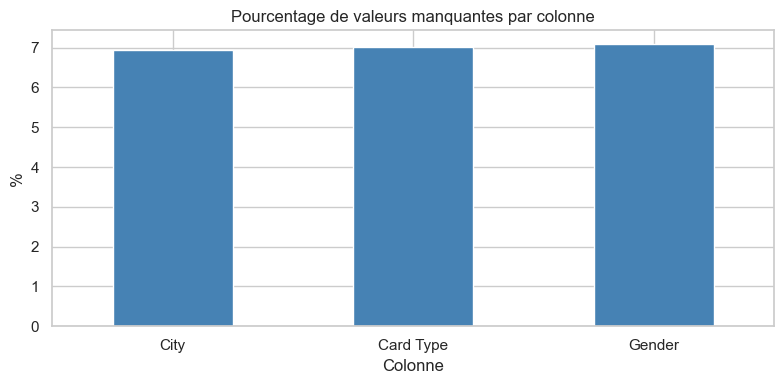

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valeurs manquantes': missing, 'Pourcentage (%)': missing_pct})
print(missing_df)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Pourcentage de valeurs manquantes par colonne')
ax.set_ylabel('%')
ax.set_xlabel('Colonne')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 2.3 Traitement des valeurs manquantes

In [6]:
# Remplacer les valeurs manquantes des colonnes catégorielles par le mode
for col in ['City', 'Card Type', 'Gender']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"  {col} : valeurs manquantes remplacées par '{mode_val}'")

print("\nValeurs manquantes après traitement :")
print(df.isnull().sum())


  City : valeurs manquantes remplacées par 'Bengaluru, India'
  Card Type : valeurs manquantes remplacées par 'Silver'
  Gender : valeurs manquantes remplacées par 'F'

Valeurs manquantes après traitement :
index           0
City         1811
Date            0
Card Type    1829
Exp Type        0
Gender       1844
Amount          0
dtype: int64


### 2.4 Suppression des doublons

In [7]:
print("Nombre de doublons :", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Dimensions après suppression des doublons :", df.shape)


Nombre de doublons : 0
Dimensions après suppression des doublons : (26052, 7)


### 2.5 Détection et traitement des valeurs aberrantes (IQR)

In [8]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print(f"Valeurs aberrantes détectées : {len(outliers)}")
print(f"Borne inférieure : {lower:.0f} | Borne supérieure : {upper:.0f}")

# Remplacement par la médiane
df['Amount'] = df['Amount'].astype(float)
median_val = df['Amount'].median()
df['Amount'] = df['Amount'].astype(float)
df.loc[df['Amount'] < lower, 'Amount'] = median_val
df.loc[df['Amount'] > upper, 'Amount'] = median_val
print(f"\nValeurs aberrantes remplacées par la médiane : {median_val:.0f}")
print("Nouvelles statistiques d'Amount :")
print(df['Amount'].describe())


Valeurs aberrantes détectées : 229
Borne inférieure : -149274 | Borne supérieure : 454445

Valeurs aberrantes remplacées par la médiane : 153106
Nouvelles statistiques d'Amount :
count     26052.000000
mean     151384.259654
std       86705.666148
min        1005.000000
25%       77120.250000
50%      153105.750000
75%      225363.000000
max      451874.000000
Name: Amount, dtype: float64


### 2.6 Vérification de la cohérence

In [9]:
print("Valeurs uniques - Card Type :", df['Card Type'].unique())
print("Valeurs uniques - Exp Type  :", df['Exp Type'].unique())
print("Valeurs uniques - Gender    :", df['Gender'].unique())
print("\nNombre de villes uniques :", df['City'].nunique())
print("\nMontants négatifs :", (df['Amount'] < 0).sum())


Valeurs uniques - Card Type : <StringArray>
['Gold', 'Platinum', 'Silver', 'Signature', nan]
Length: 5, dtype: str
Valeurs uniques - Exp Type  : <StringArray>
['Bills', 'Food', 'Entertainment', 'Grocery', 'Fuel', 'Travel']
Length: 6, dtype: str
Valeurs uniques - Gender    : <StringArray>
[nan, 'F', 'M']
Length: 3, dtype: str

Nombre de villes uniques : 983

Montants négatifs : 0


## 3. Analyse Exploratoire des Données (EDA)
### 3.1 Distribution du montant (Histogramme)

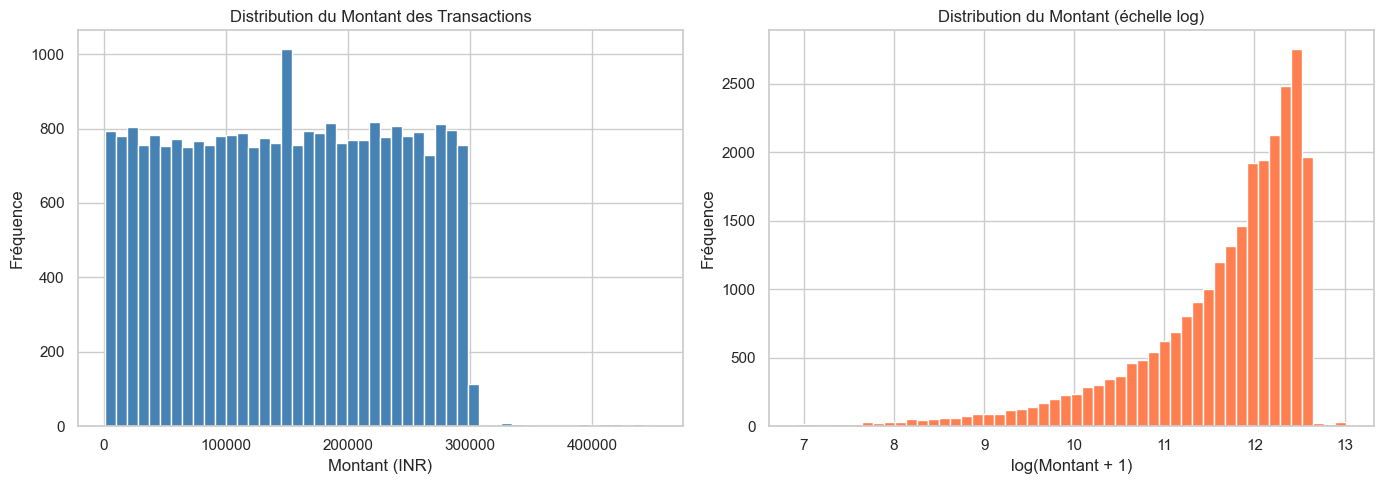

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du Montant des Transactions')
axes[0].set_xlabel('Montant (INR)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(np.log1p(df['Amount']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution du Montant (échelle log)')
axes[1].set_xlabel('log(Montant + 1)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()


### 3.2 Distributions des variables catégorielles (Count Plots)

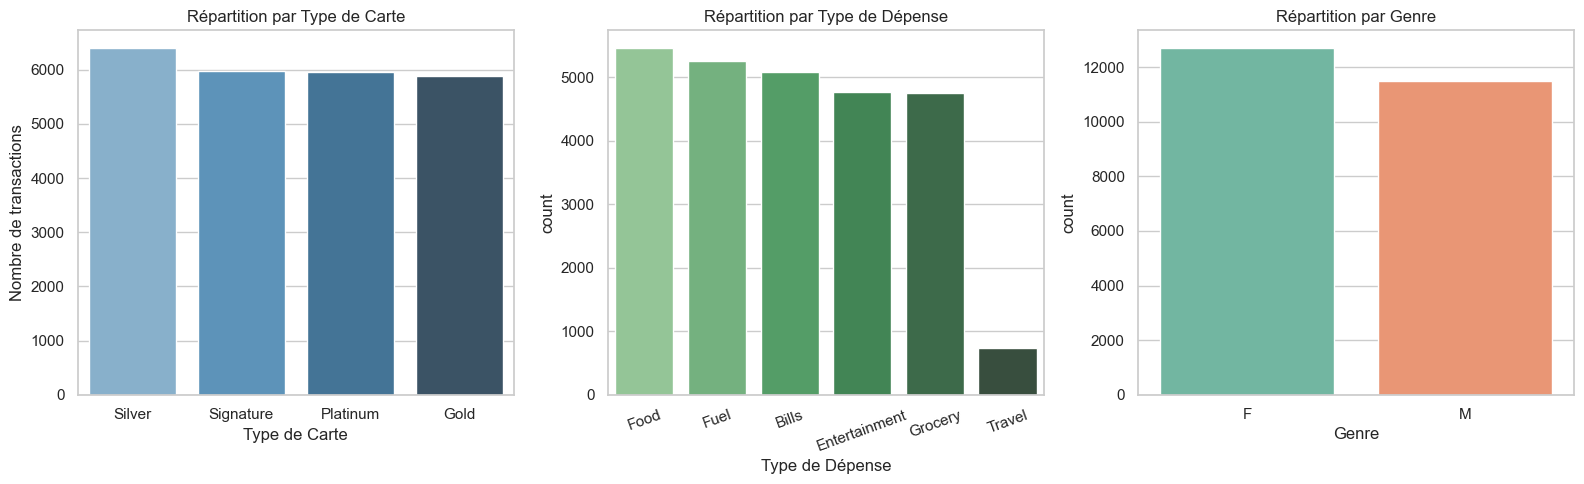

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x='Card Type', order=df['Card Type'].value_counts().index,
              palette='Blues_d', ax=axes[0])
axes[0].set_title('Répartition par Type de Carte')
axes[0].set_xlabel('Type de Carte')
axes[0].set_ylabel('Nombre de transactions')

sns.countplot(data=df, x='Exp Type', order=df['Exp Type'].value_counts().index,
              palette='Greens_d', ax=axes[1])
axes[1].set_title('Répartition par Type de Dépense')
axes[1].set_xlabel('Type de Dépense')
axes[1].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='Gender', palette='Set2', ax=axes[2])
axes[2].set_title('Répartition par Genre')
axes[2].set_xlabel('Genre')

plt.tight_layout()
plt.show()


### 3.3 Boxplots – Montant par catégorie

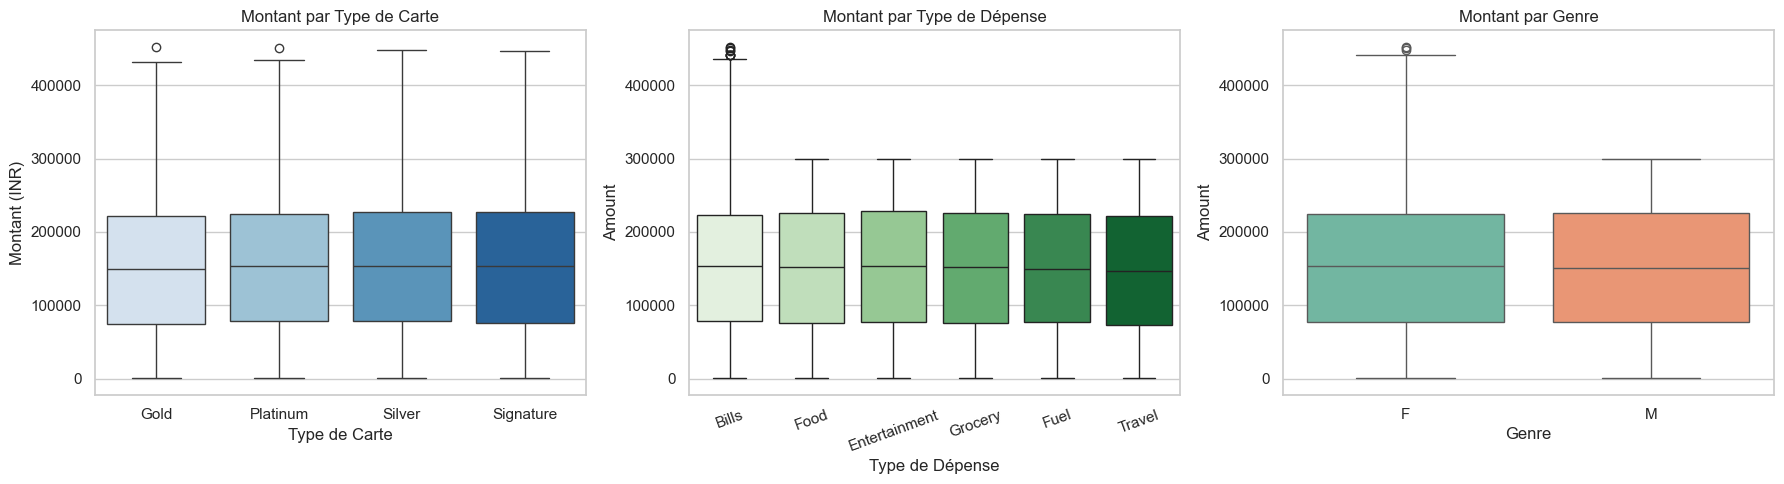

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Card Type', y='Amount', palette='Blues', ax=axes[0])
axes[0].set_title('Montant par Type de Carte')
axes[0].set_xlabel('Type de Carte')
axes[0].set_ylabel('Montant (INR)')

sns.boxplot(data=df, x='Exp Type', y='Amount', palette='Greens', ax=axes[1])
axes[1].set_title('Montant par Type de Dépense')
axes[1].set_xlabel('Type de Dépense')
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='Gender', y='Amount', palette='Set2', ax=axes[2])
axes[2].set_title('Montant par Genre')
axes[2].set_xlabel('Genre')

plt.tight_layout()
plt.show()


### 3.4 Top 10 des villes par montant total

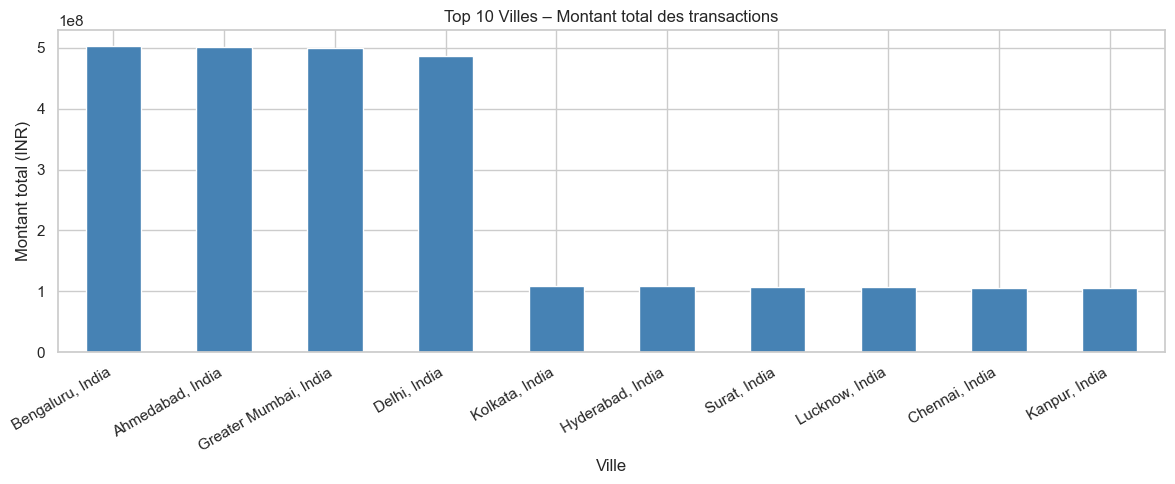

In [13]:
top_cities = df.groupby('City')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_cities.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Villes – Montant total des transactions')
plt.xlabel('Ville')
plt.ylabel('Montant total (INR)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 3.5 Évolution mensuelle des transactions

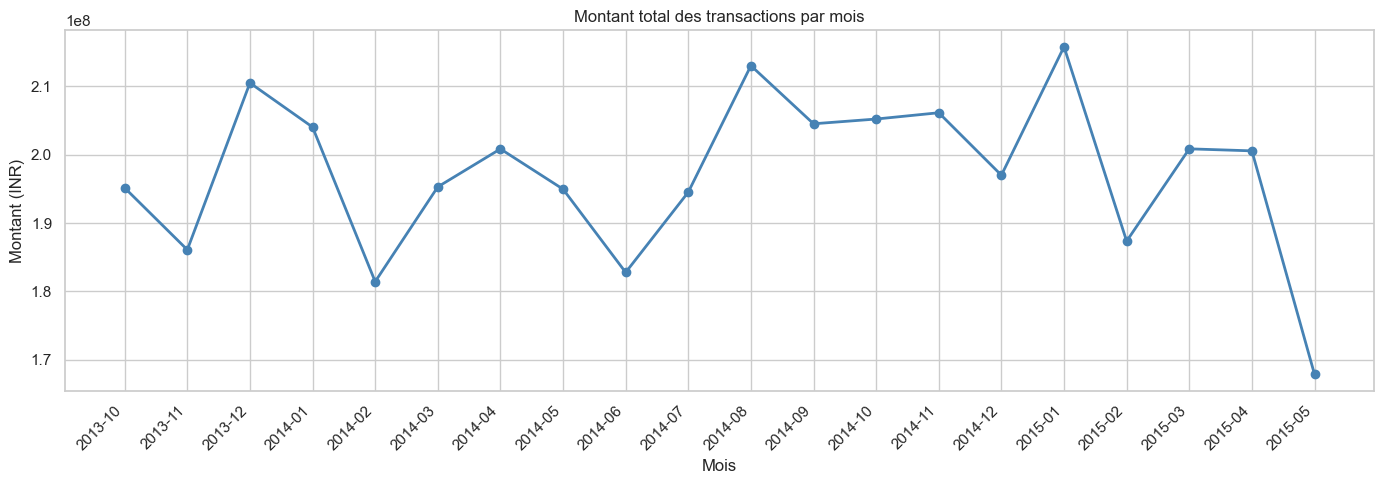

In [14]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Month')['Amount'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Month'], monthly['Amount'], marker='o', color='steelblue', linewidth=2)
plt.title('Montant total des transactions par mois')
plt.xlabel('Mois')
plt.ylabel('Montant (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 3.6 Encodage et Matrice de corrélation

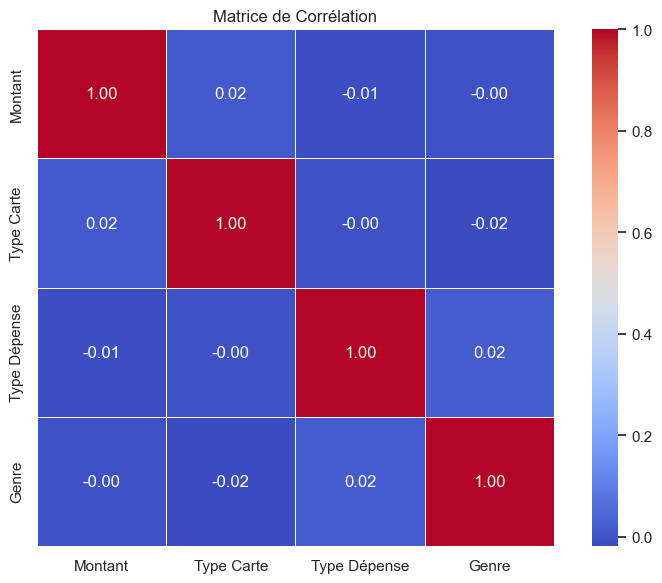

In [15]:
le = LabelEncoder()
df_enc = df.copy()
for col in ['Card Type', 'Exp Type', 'Gender']:
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col])

num_cols = ['Amount', 'Card Type_enc', 'Exp Type_enc', 'Gender_enc']
corr = df_enc[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True,
            xticklabels=['Montant','Type Carte','Type Dépense','Genre'],
            yticklabels=['Montant','Type Carte','Type Dépense','Genre'])
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()


### 3.7 Nuage de points – Montant par Type de Dépense et Genre

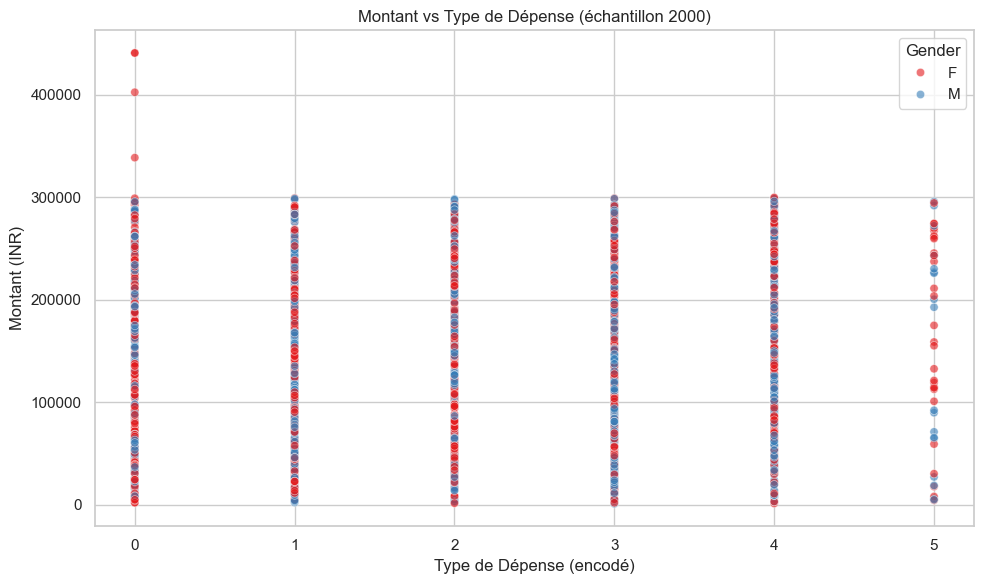

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000, random_state=42),
                x='Exp Type_enc' if 'Exp Type_enc' in df.columns else df_enc['Exp Type_enc'],
                y='Amount', hue='Gender', palette='Set1', alpha=0.6)
plt.title('Montant vs Type de Dépense (échantillon 2000)')
plt.xlabel('Type de Dépense (encodé)')
plt.ylabel('Montant (INR)')
plt.tight_layout()
plt.show()


## 4. Prétraitement pour le Clustering
### 4.1 Encodage et standardisation

In [17]:
# Encodage des variables catégorielles
le = LabelEncoder()
df_clust = df.copy()
for col in ['Card Type', 'Exp Type', 'Gender']:
    df_clust[col + '_enc'] = le.fit_transform(df_clust[col])

# Sélection des features
features = ['Amount', 'Card Type_enc', 'Exp Type_enc', 'Gender_enc']
X = df_clust[features].values

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Dimensions de la matrice de clustering :", X_scaled.shape)
print("Aperçu des données standardisées :")
print(pd.DataFrame(X_scaled, columns=features).describe().round(3))


Dimensions de la matrice de clustering : (26052, 4)
Aperçu des données standardisées :
          Amount  Card Type_enc  Exp Type_enc  Gender_enc
count  26052.000      26052.000     26052.000   26052.000
mean       0.000         -0.000        -0.000      -0.000
std        1.000          1.000         1.000       1.000
min       -1.734         -1.360        -1.420      -0.940
25%       -0.857         -0.563        -0.737      -0.940
50%        0.020          0.235        -0.054       0.672
75%        0.853          1.032         0.629       0.672
max        3.466          1.830         1.995       2.285


## 5. Clustering K-Means
### 5.1 Méthode du coude (Elbow Method)

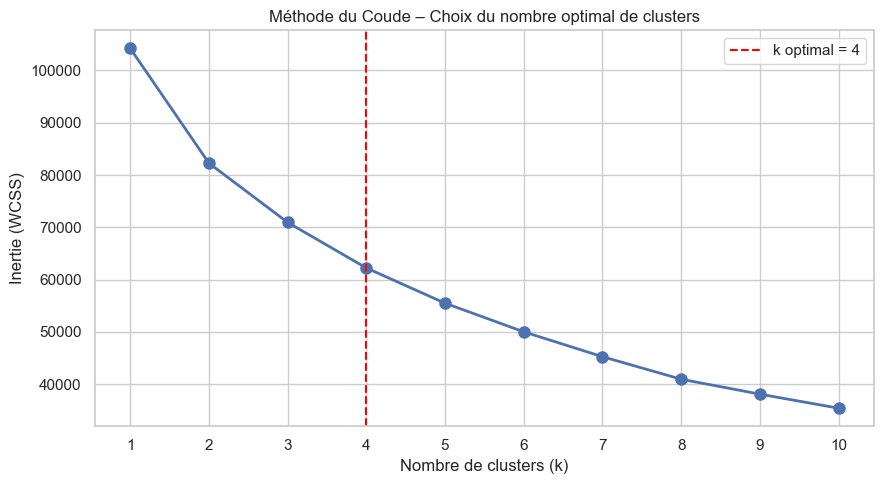

Inertie par k : {1: 104208.0, 2: 82262.4, 3: 70939.6, 4: 62223.1, 5: 55494.7, 6: 50019.0, 7: 45262.7, 8: 40957.9, 9: 38101.8, 10: 35419.7}


In [18]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='k optimal = 4')
plt.title("Méthode du Coude – Choix du nombre optimal de clusters")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (WCSS)")
plt.xticks(list(K_range))
plt.legend()
plt.tight_layout()
plt.show()
print("Inertie par k :", dict(zip(K_range, [round(i,1) for i in inertias])))


### 5.2 Application de K-Means (k=4)

In [19]:
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_clust['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print("Répartition des clusters K-Means :")
print(df_clust['KMeans_Cluster'].value_counts().sort_index())


Répartition des clusters K-Means :
KMeans_Cluster
0    7751
1    5790
2    6431
3    6080
Name: count, dtype: int64


### 5.3 Visualisation des clusters K-Means

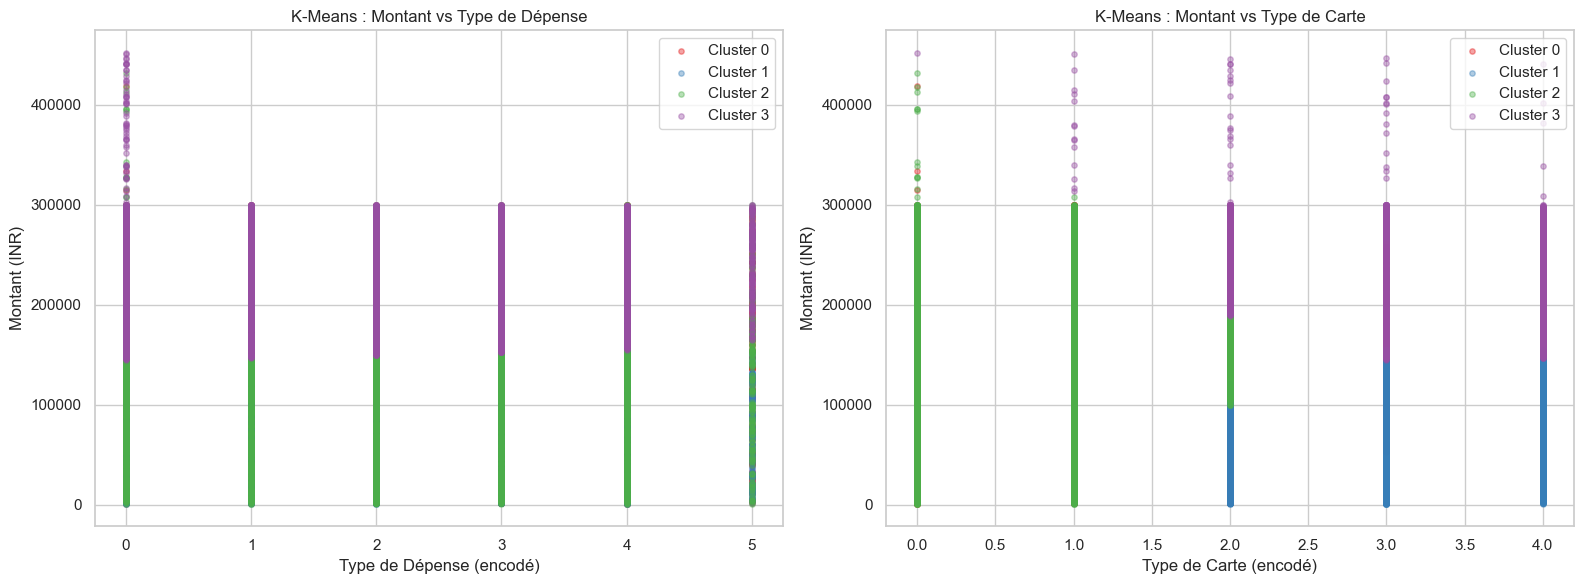

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Montant vs Type de Dépense
for c in range(k_opt):
    mask = df_clust['KMeans_Cluster'] == c
    axes[0].scatter(df_clust.loc[mask, 'Exp Type_enc'],
                    df_clust.loc[mask, 'Amount'],
                    label=f'Cluster {c}', alpha=0.4, s=15, color=palette[c])
axes[0].set_title('K-Means : Montant vs Type de Dépense')
axes[0].set_xlabel('Type de Dépense (encodé)')
axes[0].set_ylabel('Montant (INR)')
axes[0].legend()

# Montant vs Type de Carte
for c in range(k_opt):
    mask = df_clust['KMeans_Cluster'] == c
    axes[1].scatter(df_clust.loc[mask, 'Card Type_enc'],
                    df_clust.loc[mask, 'Amount'],
                    label=f'Cluster {c}', alpha=0.4, s=15, color=palette[c])
axes[1].set_title('K-Means : Montant vs Type de Carte')
axes[1].set_xlabel('Type de Carte (encodé)')
axes[1].set_ylabel('Montant (INR)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 5.4 Profil des clusters K-Means

                Nb_transactions  Montant_moyen  Montant_median  Montant_total
KMeans_Cluster                                                               
0                          7751       150186.0        150464.0   1.164093e+09
1                          5790        67674.0         65180.0   3.918319e+08
2                          6431       150228.0        153106.0   9.661139e+08
3                          6080       233853.0        236043.0   1.421824e+09


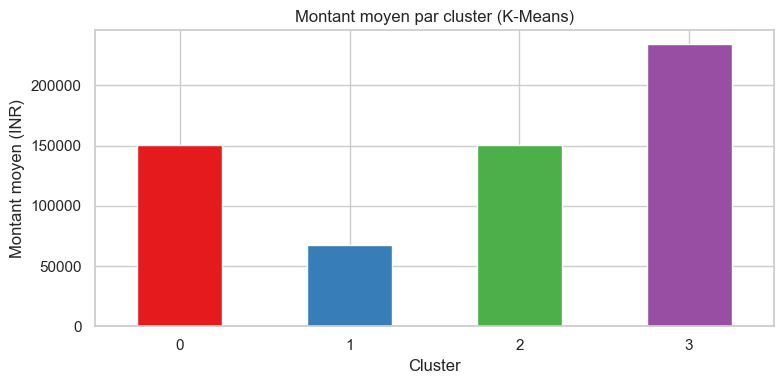

In [21]:
profile = df_clust.groupby('KMeans_Cluster').agg(
    Nb_transactions=('Amount', 'count'),
    Montant_moyen=('Amount', 'mean'),
    Montant_median=('Amount', 'median'),
    Montant_total=('Amount', 'sum')
).round(0)
print(profile)

# Histogramme du montant moyen par cluster
profile['Montant_moyen'].plot(kind='bar', color=palette, figsize=(8, 4), edgecolor='white')
plt.title('Montant moyen par cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Montant moyen (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Classification Ascendante Hiérarchique (CAH)
### 6.1 Dendrogramme

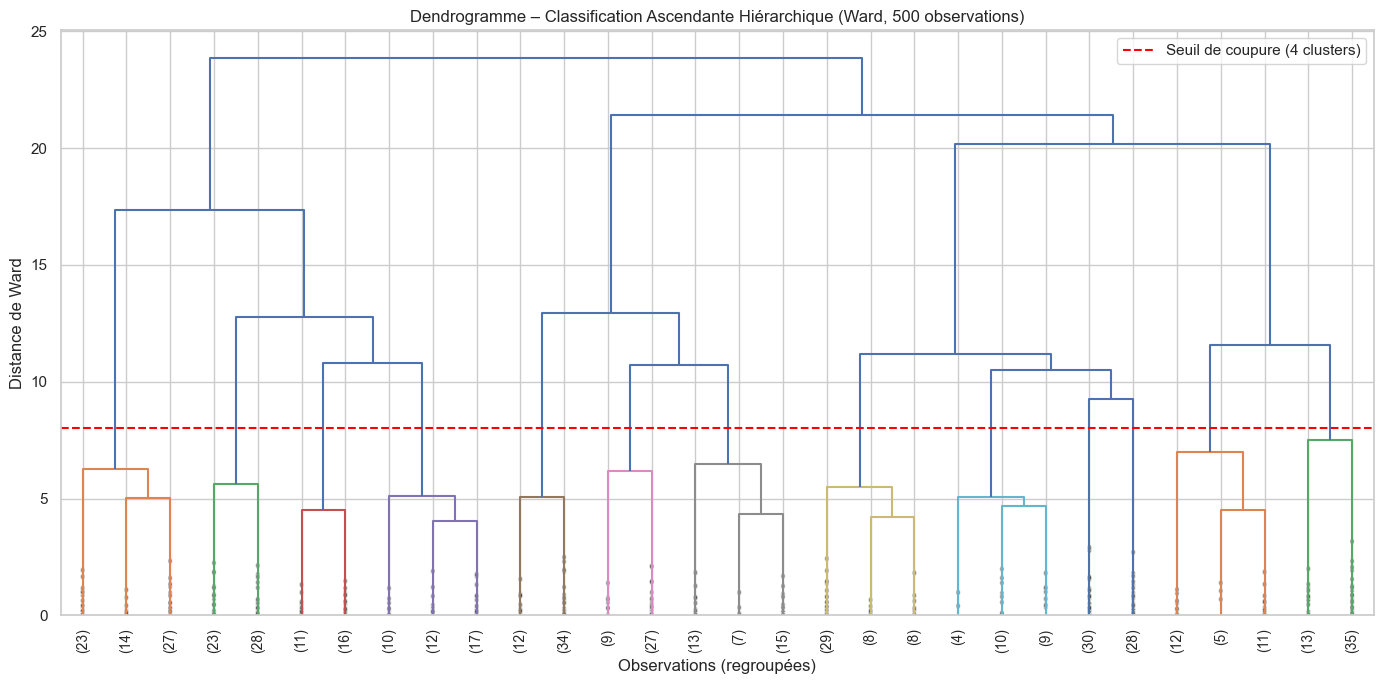

In [22]:
# Échantillon pour le dendrogramme (CAH coûteux sur 26k lignes)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=500, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True,
           color_threshold=8)
plt.axhline(y=8, color='red', linestyle='--', linewidth=1.5, label='Seuil de coupure (4 clusters)')
plt.title('Dendrogramme – Classification Ascendante Hiérarchique (Ward, 500 observations)')
plt.xlabel('Observations (regroupées)')
plt.ylabel('Distance de Ward')
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 Application de la CAH (4 clusters)

In [23]:
# CAH sur échantillon de 5000 observations pour éviter la surcharge mémoire
np.random.seed(42)
hac_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_hac = X_scaled[hac_idx]

hac = AgglomerativeClustering(n_clusters=4, linkage='ward')
hac_labels_sample = hac.fit_predict(X_hac)

# Étendre les labels à tout le dataset via KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_hac, hac_labels_sample)
df_clust['HAC_Cluster'] = knn.predict(X_scaled)

print("Répartition des clusters CAH :")
print(df_clust['HAC_Cluster'].value_counts().sort_index())


Répartition des clusters CAH :
HAC_Cluster
0    8741
1    6147
2    5875
3    5289
Name: count, dtype: int64


### 6.3 Visualisation des clusters CAH

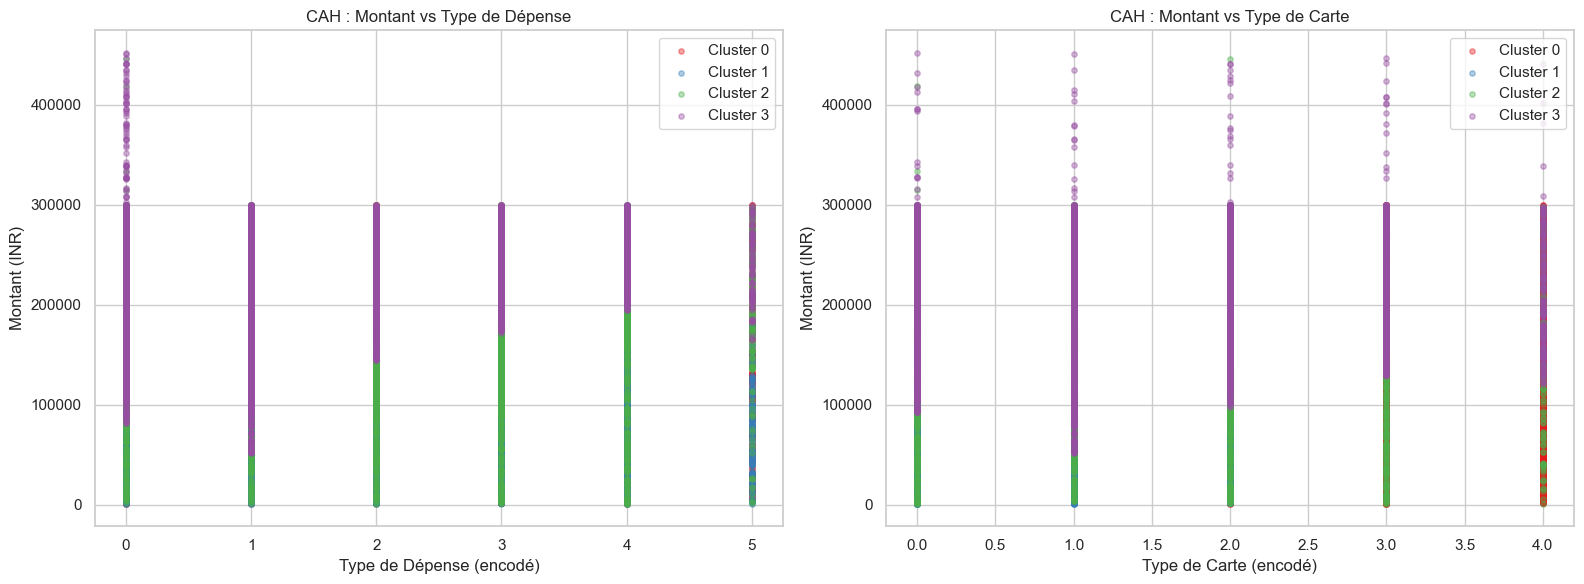

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(4):
    mask = df_clust['HAC_Cluster'] == c
    axes[0].scatter(df_clust.loc[mask, 'Exp Type_enc'],
                    df_clust.loc[mask, 'Amount'],
                    label=f'Cluster {c}', alpha=0.4, s=15, color=palette[c])
axes[0].set_title('CAH : Montant vs Type de Dépense')
axes[0].set_xlabel('Type de Dépense (encodé)')
axes[0].set_ylabel('Montant (INR)')
axes[0].legend()

for c in range(4):
    mask = df_clust['HAC_Cluster'] == c
    axes[1].scatter(df_clust.loc[mask, 'Card Type_enc'],
                    df_clust.loc[mask, 'Amount'],
                    label=f'Cluster {c}', alpha=0.4, s=15, color=palette[c])
axes[1].set_title('CAH : Montant vs Type de Carte')
axes[1].set_xlabel('Type de Carte (encodé)')
axes[1].set_ylabel('Montant (INR)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Comparaison K-Means vs CAH

In [25]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_km  = silhouette_score(X_scaled, df_clust['KMeans_Cluster'], sample_size=5000, random_state=42)
sil_hac = silhouette_score(X_scaled, df_clust['HAC_Cluster'],   sample_size=5000, random_state=42)
db_km   = davies_bouldin_score(X_scaled, df_clust['KMeans_Cluster'])
db_hac  = davies_bouldin_score(X_scaled, df_clust['HAC_Cluster'])

comp = pd.DataFrame({
    'Méthode'            : ['K-Means', 'CAH (Ward)'],
    'Score Silhouette ↑' : [round(sil_km, 4), round(sil_hac, 4)],
    'Davies-Bouldin ↓'   : [round(db_km,  4), round(db_hac,  4)]
})
print(comp.to_string(index=False))


   Méthode  Score Silhouette ↑  Davies-Bouldin ↓
   K-Means              0.1996            1.5262
CAH (Ward)              0.1587            1.6019


## 8. Sauvegarde du dataset nettoyé

In [ ]:
df_final = df_clust.drop(columns=['Month'], errors='ignore')
df_final.to_csv('projet1_cleaned.csv', index=False)
print("Dataset nettoyé sauvegardé : projet1_netoi.csv")
print("Dimensions finales :", df_final.shape)
df_final.head()


Dataset nettoyé sauvegardé : projet1_cleaned.csv
Dimensions finales : (26052, 12)


,index,City,Date,Card Type,Exp Type,Gender,Amount,Card Type_enc,Exp Type_enc,Gender_enc,KMeans_Cluster,HAC_Cluster
0,0,NaN,2014-10-29,Gold,Bills,NaN,82475.0,0,0,2,0,2
1,1,"Greater Mumbai, India",2014-08-22,Platinum,Bills,F,32555.0,1,0,0,2,1
2,2,"Bengaluru, India",2014-08-27,Silver,Bills,F,101738.0,3,0,0,1,0
3,3,"Greater Mumbai, India",2014-04-12,Signature,Bills,F,123424.0,2,0,0,2,3
4,4,"Bengaluru, India",2015-05-05,Gold,Bills,NaN,171574.0,0,0,2,0,2
